This code aims to use a PPG signal, provided from the "Cuffless Blood Pressure Estimation" Kaggle dataset to estimation blood pressure. The data is first imported, formated, and analyzed. Then, two methods of estimation are used, both based off of the equation:

        ln BP = (a * ln(HR)) + (b * ln(mNPV)) + c 
        
The first method estimates the values of the a, b, and c coefficients using a linear least squares calculation. These coefficients can then be applied to other data to estimate blood pressure. The second method uses machine learning and a multiple regression model to estimate blood pressure. In both methods, two trials are done: the first with the average blood pressure (average values of mmHg over the course of a minute) and the second with mean arterial pressure. 

**Necessary Libraries, Data, and Formatting**

In [1]:
# importing libraries
import numpy as np # For numerical computation
import pandas as pd # Data manipulation
import seaborn as sns # plotting
import scipy.io # reading matlab files in python
from scipy import signal #signal processing
from scipy.fftpack import fft, dct #signal processing

from sklearn.linear_model import LinearRegression #linear regression model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split # cross validation split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from matplotlib import pyplot as plt # For plotting graphs(Visualization)

import os # system-wide functions
os.listdir('/kaggle/input/BloodPressureDataset')

['part_4.mat',
 'part_9.mat',
 'part_10.mat',
 'Samples',
 'part_11.mat',
 'part_3.mat',
 'part_1.mat',
 'part_8.mat',
 'part_5.mat',
 'part_6.mat',
 'part_7.mat',
 'part_2.mat',
 'part_12.mat']

In [2]:
#loading a file 
sample_file = scipy.io.loadmat(f'../input/BloodPressureDataset/part_{1}.mat')
print(f'sample_file Data type: {type(sample_file)}')
print(f'sample_file keys:\n{sample_file.keys()}')

sample_file Data type: <class 'dict'>
sample_file keys:
dict_keys(['__header__', '__version__', '__globals__', 'p'])


In [3]:
# Loading a sample .mat file to understand the data dimensions
test_sample = scipy.io.loadmat(f'../input/BloodPressureDataset/part_{1}.mat')['p']
print(f'test_sample Data type: {type(test_sample)}')
print(f'test_sample shape/dimensions: {test_sample.shape}')

test_sample Data type: <class 'numpy.ndarray'>
test_sample shape/dimensions: (1, 1000)


In [4]:
#determining more sample info

print(f"Total Samples: {len(test_sample[0])}")
print(f"Number of readings in each sample(column): {len(test_sample[0][0])}")
print(f"Number of samples in each reading(ECG): {len(test_sample[0][0][2])}")

temp_mat = test_sample[0, 999]
temp_length = temp_mat.shape[1]
sample_size = 125

Total Samples: 1000
Number of readings in each sample(column): 3
Number of samples in each reading(ECG): 61000


In [5]:
#arranging ppg data in a list 
sample_size = 125
ppg = []
for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ppg = temp_mat[0, j*sample_size:(j+1)*sample_size]
        ppg.append(temp_ppg)

In [6]:
#arranging other vitals into lists 

ecg = []
bp = []
sbp = [] #Systolic Blood Pressure
dbp = [] #Diastolic Blood Pressue
size = 125 #sample size

for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ecg = temp_mat[2, j*size:(j+1)*size]
        temp_bp = temp_mat[1, j*size:(j+1)*size]
        
        max_value = max(temp_bp)
        min_value = min(temp_bp)
        sbp.append(max_value)
        dbp.append(min_value)
        ecg.append(temp_ecg)
        bp.append(temp_bp)

In [7]:
# Reshaping the ecg, ppg and bp signal data into column vectors
ppg, ecg, bp = np.array(ppg).reshape(-1,1), np.array(ecg).reshape(-1,1), np.array(bp).reshape(-1,1)
sbp, dbp = np.array(sbp).reshape(-1,1), np.array(dbp).reshape(-1,1)
print(f'PPG_shape: {ppg.shape}\n ECG_shape: {ecg.shape}\n BP_shape: {bp.shape}')
print(f'Systolic-BP_shape: {sbp.shape},\n Diastolic-BP_shape: {dbp.shape}')

PPG_shape: (32061000, 1)
 ECG_shape: (32061000, 1)
 BP_shape: (32061000, 1)
Systolic-BP_shape: (256488, 1),
 Diastolic-BP_shape: (256488, 1)


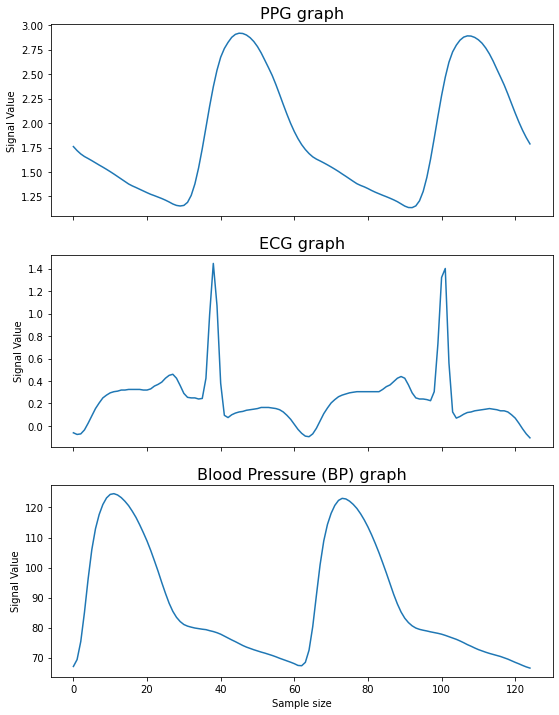

In [8]:
##plotting sample ppg, ecg and bp signals
##using a sample size of 125
fig, ax = plt.subplots(3,1, figsize=(9,12), sharex=True)

ax[0].set_title('PPG graph', fontsize=16)
ax[0].set_ylabel('Signal Value')
ax[0].plot(ppg[:125])

ax[1].set_title('ECG graph', fontsize=16)
ax[1].set_ylabel('Signal Value')
ax[1].plot(ecg[:125])

ax[2].set_title('Blood Pressure (BP) graph', fontsize=16)
ax[2].set_ylabel('Signal Value')
ax[2].set_xlabel('Sample size')
ax[2].plot(bp[:125])

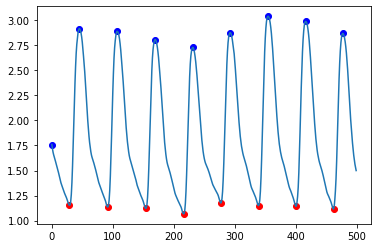

In [9]:
#importing and testing peak detection algorithm 

import sys
from numpy import NaN, Inf, arange, isscalar, asarray, array

def peakdet(v, delta, x = None):
    """
    Converted from MATLAB script at http://billauer.co.il/peakdet.html
    
    Returns two arrays
    
    function [maxtab, mintab]=peakdet(v, delta, x)
    %PEAKDET Detect peaks in a vector
    %        [MAXTAB, MINTAB] = PEAKDET(V, DELTA) finds the local
    %        maxima and minima ("peaks") in the vector V.
    %        MAXTAB and MINTAB consists of two columns. Column 1
    %        contains indices in V, and column 2 the found values.
    %      
    %        With [MAXTAB, MINTAB] = PEAKDET(V, DELTA, X) the indices
    %        in MAXTAB and MINTAB are replaced with the corresponding
    %        X-values.
    %
    %        A point is considered a maximum peak if it has the maximal
    %        value, and was preceded (to the left) by a value lower by
    %        DELTA.
    
    % Eli Billauer, 3.4.05 (Explicitly not copyrighted).
    % This function is released to the public domain; Any use is allowed.
    
    """
    maxtab = []
    mintab = []
       
    if x is None:
        x = arange(len(v))
    
    v = asarray(v)
    
    if len(v) != len(x):
        sys.exit('Input vectors v and x must have same length')
    
    if not isscalar(delta):
        sys.exit('Input argument delta must be a scalar')
    
    if delta <= 0:
        sys.exit('Input argument delta must be positive')
    
    mn, mx = Inf, -Inf
    mnpos, mxpos = NaN, NaN
    
    lookformax = True
    
    for i in arange(len(v)):
        this = v[i]
        if this > mx:
            mx = this
            mxpos = x[i]
        if this < mn:
            mn = this
            mnpos = x[i]
        
        if lookformax:
            if this < mx-delta:
                maxtab.append((mxpos, mx))
                mn = this
                mnpos = x[i]
                lookformax = False
        else:
            if this > mn+delta:
                mintab.append((mnpos, mn))
                mx = this
                mxpos = x[i]
                lookformax = True

    return array(maxtab), array(mintab)

if __name__=="__main__":
    from matplotlib.pyplot import plot, scatter, show
    series = ppg[:500]
    maxtab, mintab = peakdet(series,.3)
    plot(series)
    scatter(array(maxtab)[:,0], array(maxtab)[:,1], color='blue')
    scatter(array(mintab)[:,0], array(mintab)[:,1], color='red')
    show()

In [10]:
#code used to find peak-to-peak amplitude 

top = []
for p in range(len(maxtab)-1):
    lum_max = maxtab[p+1][1][0]
    top.append(lum_max)
avg_top = np.mean(top)
#print(avg_top)

bottom = []
for q in range(len(mintab)):
    lum_min = mintab[p][1][0]
    bottom.append(lum_min)
avg_bottom = np.mean(bottom)
#print(avg_bottom)


amp = abs(avg_top - avg_bottom)
#print(amp)

****Approach 1: Determining Coefficients by Linear Least Square Calculations ****

In [11]:
#creating array of MAP values 

MAP_array = []
mean_systolic = []
mean_diastolic = []

if __name__=="__main__":
    from matplotlib.pyplot import plot, scatter, show
    for i in range(500):
        analysis = bp[i*7500:(i+1)*7500]
        sys, dia = peakdet(analysis,.3)
        
        systolic = []
        for p in range(len(sys)):
            s = sys[p][1][0]
            systolic.append(s)
        avg_systolic = np.mean(systolic)
        mean_systolic.append(avg_systolic)
            
        diastolic = []
        for q in range(len(dia)):
            d = dia[q][1][0]
            diastolic.append(d)
        avg_diastolic = np.mean(diastolic)
        mean_diastolic.append(avg_diastolic)
            
        MAP = (mean_systolic[i] + (2*mean_diastolic[i])) /3 
        MAP_array.append(MAP)
    #print(mean_systolic)
    #print(mean_diastolic)
    #print(MAP_array)
    

In [12]:
#calculates B array, which is made up of HR, mNPV, and 1s
import math
B1 = []
if __name__=="__main__":
    from matplotlib.pyplot import plot, scatter, show
    #series = ppg
    #maxs, mins = peakdet(series,.3)
    for i in range(500):
        series = ppg[i*7500:(i+1)*7500]
        maxs, mins = peakdet(series,.3)
        peaks = len(maxs)-1
        #HR = math.log(peaks * 2)
        HR = math.log(len(maxs)-1)
        top = []
        for p in range(len(maxs)-1):
            lum_max = maxs[p+1][1][0]
            top.append(lum_max)
        avg_top = np.mean(top)
        bottom = []
        for q in range(len(mins)):
            lum_min = mins[q][1][0]
            bottom.append(lum_min)
        avg_bottom = np.mean(bottom)
        amp = abs(avg_top - avg_bottom)
        mNPV = math.log(amp / np.mean(ppg[(i*7500):(i+1)*7500]))
        B1.append([HR, mNPV, 1])
    
#print(B1)
#print('')
B_array = np.array(B1)
#print(B_array)
B_array_T = B_array.transpose()
#print('')
#print(B_array_T)

In [13]:
#Linear Least Squares Calculation
inner = np.dot(B_array_T, B1)  #B transpose times B
inverse = np.linalg.inv(inner) #taking the inverse
outer = np.dot(inverse, B_array_T) #multiplying by the tranpose again 


In [14]:
#creating the A array of average blood pressure samples 

A = []
for c in range(500):
    points = bp[(c)*7500:(c+1)*7500]
    #MAP = np.mean(points)
    average_BP = math.log(np.mean(points))
    A.append(average_BP)
#print(A)
#print(" ")
#print(A[:3])

In [15]:
#estimate a, b, and c values based upon averaged blood pressure

estimate = np.dot(outer, A)
print(estimate)

[-0.11167305 -0.00977266  4.98568563]


In [16]:
#estimte a, b, and c values based upon averaged MAP 

estimation2 = np.dot(outer, MAP_array)
print(estimation2)

[ -6.04849852  29.66038524 115.4897122 ]


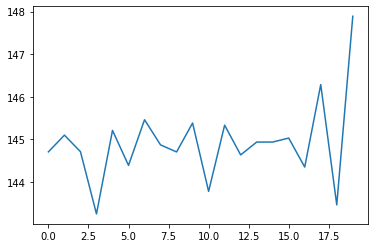

In [17]:
## Code that can be used to check estimated BP vs actual BP data 
BP_array = []
for t in range(20):
    values = ppg[t*7500:(t+1)*7500]
    maxs, mins = peakdet(series,.3)
    peaks = len(maxs)-1
    HR = math.log(len(maxs)-1)
    top = []
    for m in range(len(maxs)-1):
        lum_max = maxs[m+1][1][0]
        top.append(lum_max)
        avg_top = np.mean(top)
    bottom = []
    for n in range(len(mins)):
        lum_min = mins[n][1][0]
        bottom.append(lum_min)
        avg_bottom = np.mean(bottom)
    amp = abs(avg_top - avg_bottom)
    mNPV = abs(math.log(amp / np.mean(ppg[(t*7500):(t+1)*7500])))
    BP = math.exp((-0.13894365* math.log(HR)) + (-0.02209914 * math.log(mNPV)) + (5.10754246))
    BP_array.append(BP)

#print(BP_array)
plt.plot(BP_array)

In [18]:
#code that can be used to calculate the error between estimated and true BP values 

BP_new = np.array(BP_array)
difference = np.subtract(BP_new, bp[:10])
#print(difference)



for z in range(20):
    diff = BP_new[z] - bp[z]
    div = diff / bp[i]
    error = div * 100
    print(error)


[69.53915173]
[67.83477579]
[62.10545394]
[52.13645349]
[43.87415618]
[34.43453883]
[29.13765748]
[24.36578111]
[21.24304225]
[19.88253251]
[17.39574888]
[18.56884294]
[18.33756832]
[19.39471754]
[20.48905424]
[21.88487762]
[22.93799172]
[26.50864913]
[26.16667137]
[32.49465654]


**Approach 2: Using ML with a multiple regression model***

2a. Using average blood pressure 

In [19]:
from sklearn import linear_model

In [20]:
#calculates B array, which is made up of HR, mNPV, and 1s (repeated code)

import math
HR_arr = []
mNPV_arr = []
B1 = []
if __name__=="__main__":
    from matplotlib.pyplot import plot, scatter, show
    #series = ppg
    #maxs, mins = peakdet(series,.3)
    for i in range(500):
        series = ppg[i*7500:(i+1)*7500]
        maxs, mins = peakdet(series,.3)
        peaks = len(maxs)-1
        #HR = math.log(peaks * 60)
        HR = math.log(len(maxs)-1)
        HR_arr.append(HR)
        top = []
        for p in range(len(maxs)-1):
            lum_max = maxs[p+1][1][0]
            top.append(lum_max)
            avg_top = np.mean(top)
        bottom = []
        for q in range(len(mins)):
            lum_min = mins[q][1][0]
            bottom.append(lum_min)
            avg_bottom = np.mean(bottom)
        amp = abs(avg_top - avg_bottom)
        mNPV = math.log(amp / np.mean(ppg[(i*7500):(i+1)*7500]))
        mNPV_arr.append(mNPV)
        B1.append([HR, mNPV, 1])
    

B_array = np.array(B1)
B_array_T = B_array.transpose()
#print(HR_arr)
#print(mNPV_arr)

In [21]:
#creating the A array of average blood pressure samples (repeated code)

A_2= []
for i in range(500):
        points = bp[(i)*7500:(i+1)*7500]
        average_BP2 = math.log(np.mean(points))
        A_2.append(average_BP2)

In [22]:
#define X and Y variables 
X = np.array([[HR_arr], [mNPV_arr]])
Y = np.array(A_2)

In [23]:
#reshape the inputs 
X = X.reshape(-2, 500)
Y = Y.reshape(-1, 1)
Z = X.transpose()

In [24]:
# instantiate model
model = linear_model.LinearRegression()
# fit model
model.fit(Z, Y)

LinearRegression()

In [25]:
#predict average blood pressure (for 1 minute) based off of ln(HR) and ln(mNPV)
value = model.predict([[4.812, -0.0404]])
ans = math.exp(value[0][0])
print(ans)

85.5165315554999


2b. Using MAP estimation

In [26]:
#define X and Y variables; reshape them 
Xb = np.array([[HR_arr], [mNPV_arr]])
Yb = np.array(MAP_array)

Xb = Xb.reshape(-2, 500)
Yb = Yb.reshape(-1, 1)
Zb = Xb.transpose()

In [27]:
# instantiate model
model2b = linear_model.LinearRegression()
# fit model
model2b.fit(Zb, np.log(Yb))

LinearRegression()

In [28]:
#predict based average MAP blood pressure (for 1 minute) off of ln(HR) and ln(mNPV)
value2b = model2b.predict([[4.812, -0.0404]])
ans2b = math.exp(value2b[0][0])
print(ans2b)

84.65483081229617


Testing Estimation Models 

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(Zb, Yb, test_size = 0.3, random_state = 0)

In [30]:
# instantiate 
model = LinearRegression()
# fit
model.fit(X_train, y_train)
# predict
y_pred = model.predict(X_test)

In [31]:
#R2 score for estimation method 2b 
score = r2_score(y_test, y_pred)
print(score)

0.08597577066356732
